In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [3]:
df['salary_currency'].unique()

array(['USD', 'INR', 'EUR', 'CAD', 'GBP', 'MXN', 'HUF', 'JPY', 'DKK',
       'CNY', 'SGD', 'AUD', 'PLN', 'TRY', 'CLP', 'BRL', 'CHF', 'CZK',
       'HKD', 'ILS', 'THB'], dtype=object)

In [4]:
df['job_title'].unique()

array(['Staff Data Analyst', 'Business Data Analyst', 'Data Engineer',
       'Data Analyst', 'Data Scientist', 'Machine Learning Manager',
       'Product Data Analyst', 'Big Data Engineer', 'Research Scientist',
       'Data Science Consultant', 'Machine Learning Engineer',
       'Machine Learning Infrastructure Engineer', 'ML Engineer',
       'Lead Data Scientist', 'Machine Learning Scientist',
       'Lead Data Engineer', 'Lead Data Analyst', 'BI Data Analyst',
       'Director of Data Science', 'AI Scientist',
       'Computer Vision Engineer', 'Principal Data Scientist',
       'Data Science Manager', 'Data Engineering Manager',
       'Data Science Lead', 'Marketing Data Engineer',
       '3D Computer Vision Researcher', 'Autonomous Vehicle Technician',
       'Power BI Developer', 'Machine Learning Research Engineer',
       'Machine Learning Developer', 'Computer Vision Software Engineer',
       'Cloud Data Architect', 'Head of Data',
       'Applied Machine Learning Scient

In [5]:
df['job_title'].value_counts().head(11)

job_title
Data Engineer                 730
Data Scientist                681
Data Analyst                  493
Machine Learning Engineer     247
Analytics Engineer             95
Research Scientist             81
Data Architect                 75
Data Science Manager           64
ML Engineer                    40
Machine Learning Scientist     34
Research Engineer              33
Name: count, dtype: int64

In [6]:
clean = df.copy()

In [7]:
clean = clean[['job_title','work_year','salary','salary_in_usd','salary_currency']]

In [8]:
clean.loc[clean['job_title'] == 'ML Engineer'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 23 to 3147
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        40 non-null     object
 1   work_year        40 non-null     int64 
 2   salary           40 non-null     int64 
 3   salary_in_usd    40 non-null     int64 
 4   salary_currency  40 non-null     object
dtypes: int64(3), object(2)
memory usage: 1.9+ KB


In [9]:
clean['job_title'] = clean['job_title'].replace({'ML Engineer': 'Machine Learning Engineer'})

In [10]:
clean['job_title'].value_counts()

job_title
Data Engineer                730
Data Scientist               681
Data Analyst                 493
Machine Learning Engineer    287
Analytics Engineer            95
                            ... 
Compliance Data Analyst        1
Data DevOps Engineer           1
BI Data Engineer               1
Deep Learning Researcher       1
Azure Data Engineer            1
Name: count, Length: 94, dtype: int64

In [11]:
clean_2 = clean.loc[(clean['salary_currency'] == 'USD') | (clean['salary_currency'] == 'CAD') | (clean['salary_currency'] == 'GBP')]
clean_2.reset_index()

,index,job_title,work_year,salary,salary_in_usd,salary_currency
0,0,Staff Data Analyst,2020,15000,15000,USD
1,1,Business Data Analyst,2020,95000,95000,USD
2,5,Machine Learning Manager,2020,157000,117104,CAD
3,7,Product Data Analyst,2020,20000,20000,USD
4,9,Big Data Engineer,2020,70000,70000,USD
...,...,...,...,...,...,...
2731,3186,Data Engineer,2023,182000,182000,USD
2732,3187,Machine Learning Engineer,2023,261500,261500,USD
2733,3188,Machine Learning Engineer,2023,134500,134500,USD
2734,3189,Data Scientist,2023,130000,130000,USD


In [12]:
clean_2['job_title'].nunique()

86

In [13]:
clean_2 = clean_2.drop_duplicates(subset=['job_title']).reset_index()

In [14]:
clean_2

,index,job_title,work_year,salary,salary_in_usd,salary_currency
0,0,Staff Data Analyst,2020,15000,15000,USD
1,1,Business Data Analyst,2020,95000,95000,USD
2,5,Machine Learning Manager,2020,157000,117104,CAD
3,7,Product Data Analyst,2020,20000,20000,USD
4,9,Big Data Engineer,2020,70000,70000,USD
...,...,...,...,...,...,...
81,2675,Software Data Engineer,2023,50000,50000,USD
82,2769,Insight Analyst,2023,42000,51039,GBP
83,2778,Applied Machine Learning Engineer,2023,130000,130000,USD
84,2940,Azure Data Engineer,2023,100000,100000,USD


In [15]:
clean_2.loc[clean_2['salary_currency'] == 'CAD']

,index,job_title,work_year,salary,salary_in_usd,salary_currency
2,5,Machine Learning Manager,2020,157000,117104,CAD
34,208,Data Science Engineer,2021,159500,127221,CAD
39,266,Big Data Architect,2021,125000,99703,CAD


In [16]:
clean_2 = clean_2[['job_title','work_year','salary','salary_in_usd']]
clean_2

,job_title,work_year,salary,salary_in_usd
0,Staff Data Analyst,2020,15000,15000
1,Business Data Analyst,2020,95000,95000
2,Machine Learning Manager,2020,157000,117104
3,Product Data Analyst,2020,20000,20000
4,Big Data Engineer,2020,70000,70000
...,...,...,...,...
81,Software Data Engineer,2023,50000,50000
82,Insight Analyst,2023,42000,51039
83,Applied Machine Learning Engineer,2023,130000,130000
84,Azure Data Engineer,2023,100000,100000


In [17]:
clean_3 = clean_2.set_index('job_title')
clean_3

,work_year,salary,salary_in_usd
job_title,,,
Staff Data Analyst,2020,15000,15000
Business Data Analyst,2020,95000,95000
Machine Learning Manager,2020,157000,117104
Product Data Analyst,2020,20000,20000
Big Data Engineer,2020,70000,70000
...,...,...,...
Software Data Engineer,2023,50000,50000
Insight Analyst,2023,42000,51039
Applied Machine Learning Engineer,2023,130000,130000


In [18]:
clean_3.mean()

work_year          2021.395349
salary           138480.406977
salary_in_usd    138721.511628
dtype: float64

In [19]:
scaler = StandardScaler(with_std=True,
                        with_mean=True)
dsjobs_scaled = scaler.fit_transform(clean_3)
pcaDS = PCA()

In [20]:
pcaDS.fit(dsjobs_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [21]:
pcaDS.mean_

array([8.95459417e-14, 2.19462691e-17, 1.54914841e-16])

In [22]:
scores = pcaDS.transform(dsjobs_scaled)

In [23]:
pcaDS.components_ 

array([[-0.00292019,  0.707112  ,  0.70709553],
       [ 0.99996393, -0.00357483,  0.00770461],
       [ 0.00797577,  0.70709252, -0.70707606]])

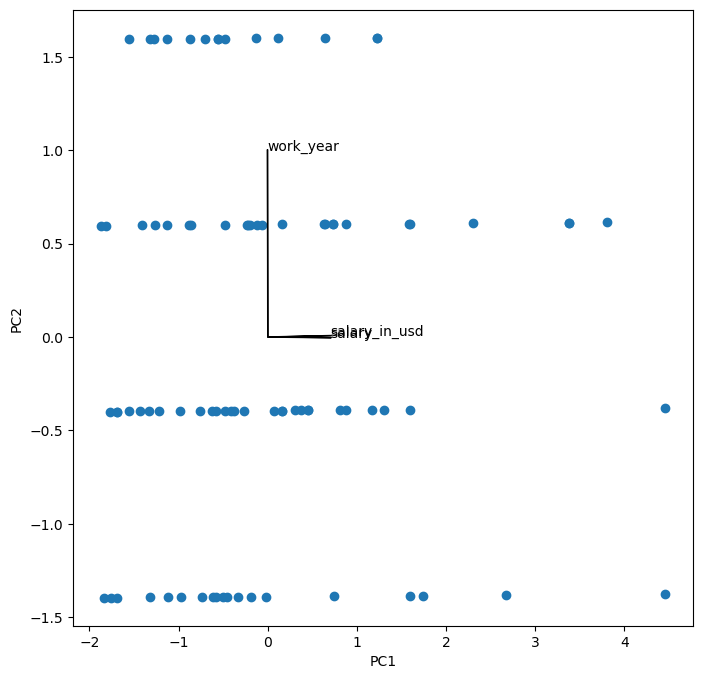

In [24]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaDS.components_.shape[1]):
    ax.arrow(0, 0, pcaDS.components_[i,k], pcaDS.components_[j,k])
    ax.text(pcaDS.components_[i,k],
            pcaDS.components_[j,k],
            clean_3.columns[k])

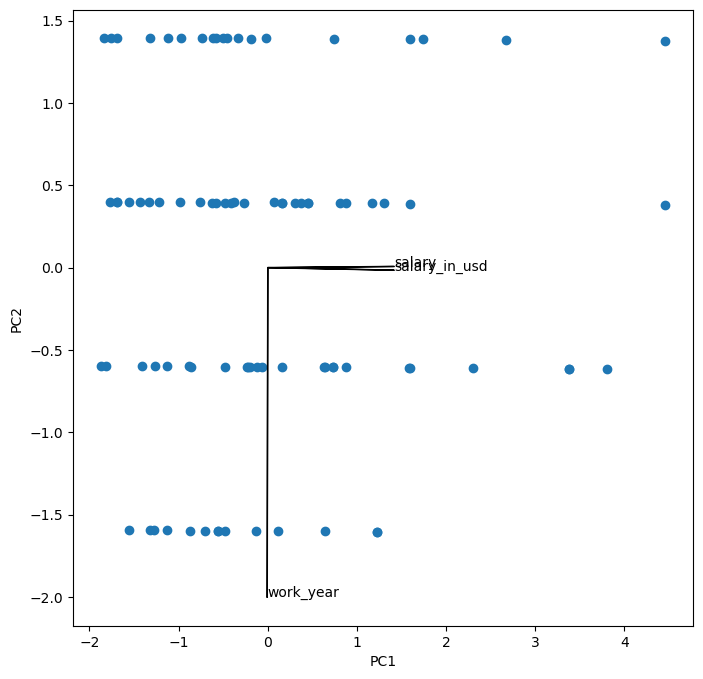

In [25]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pcaDS.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaDS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaDS.components_[i,k], s_*pcaDS.components_[j,k])
    ax.text(s_*pcaDS.components_[i,k],
            s_*pcaDS.components_[j,k],
            clean_3.columns[k])

In [26]:
scores.std(0, ddof=1)

array([1.42125613, 1.00589276, 0.05920209])

In [27]:
pcaDS.explained_variance_


array([2.01996898, 1.01182025, 0.00350489])

In [28]:
pcaDS.explained_variance_ratio_

array([0.66549366, 0.33335163, 0.00115471])

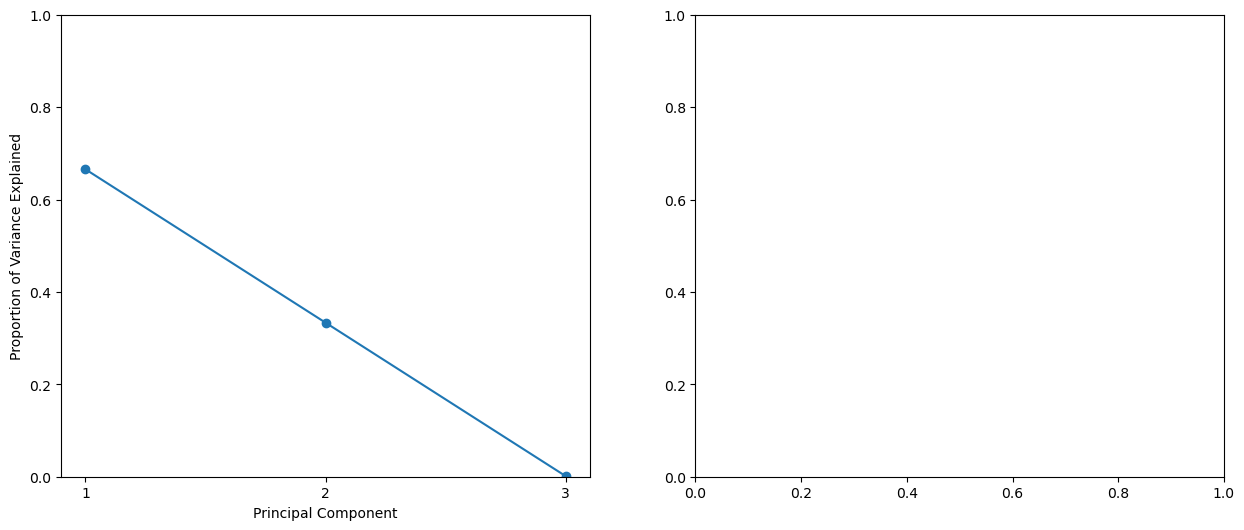

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pcaDS.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pcaDS.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)

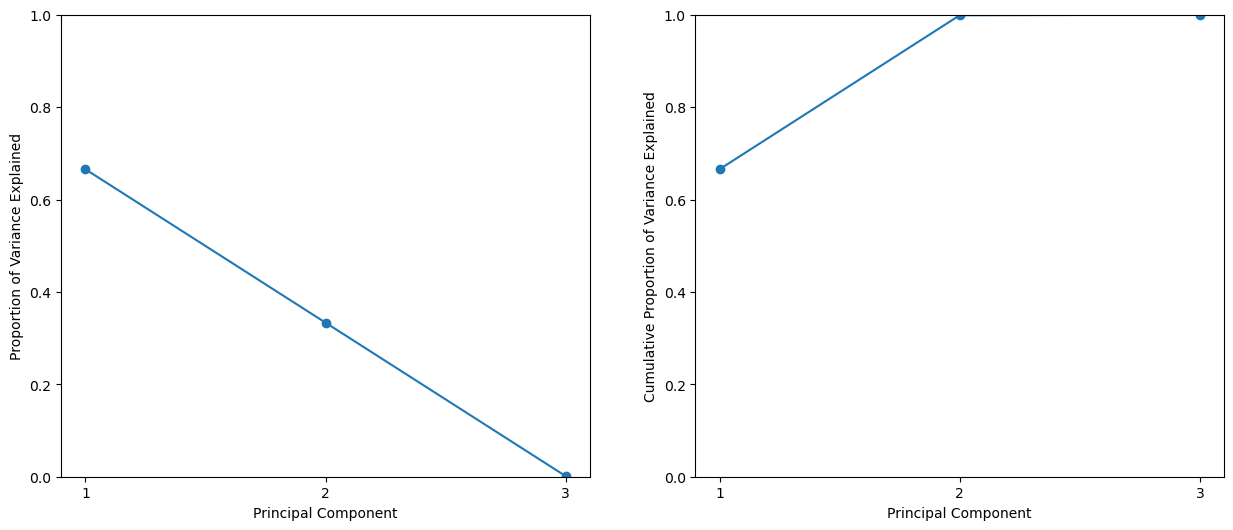

In [32]:
ax = axes[1]
ax.plot(ticks,
        pcaDS.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig


In [33]:
X = dsjobs_scaled
U, D, V = np.linalg.svd(X, full_matrices=False)
U.shape, D.shape, V.shape

((86, 3), (3,), (3, 3))

In [34]:
V

array([[ 0.00292019, -0.707112  , -0.70709553],
       [-0.99996393,  0.00357483, -0.00770461],
       [-0.00797577, -0.70709252,  0.70707606]])

In [35]:
pcaDS.components_

array([[-0.00292019,  0.707112  ,  0.70709553],
       [-0.99996393,  0.00357483, -0.00770461],
       [ 0.00797577,  0.70709252, -0.70707606]])

In [36]:
(U * D[None,:])[:3]

array([[ 1.76234108,  1.39601625,  0.0029249 ],
       [ 0.61905137,  1.39264424,  0.00709662],
       [ 0.01912137,  1.39314852, -0.27578195]])

In [37]:
scores[:3]

array([[-1.76234108,  1.39601625, -0.0029249 ],
       [-0.61905137,  1.39264424, -0.00709662],
       [-0.01912137,  1.39314852,  0.27578195]])

In [38]:
n_omit = 20
np.random.seed(15)
r_idx = np.random.choice(np.arange(X.shape[0]),
                         n_omit,
                         replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]),
                         n_omit,
                         replace=True)
Xna = X.copy()
Xna[r_idx, c_idx] = np.nan

In [39]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:,:M] * D[None,:M]
    return L.dot(V[:M])

In [40]:
Xhat = Xna.copy()
Xbar = np.nanmean(Xhat, axis=0)
Xhat[r_idx, c_idx] = Xbar[c_idx]

In [41]:
thresh = 1e-7
rel_err = 1
count = 0
ismiss = np.isnan(Xna)
mssold = np.mean(Xhat[~ismiss]**2)
mss0 = np.mean(Xna[~ismiss]**2)

In [42]:
while rel_err > thresh:
    count += 1
    # Step 2(a)
    Xapp = low_rank(Xhat, M=1)
    # Step 2(b)
    Xhat[ismiss] = Xapp[ismiss]
    # Step 2(c)
    mss = np.mean(((Xna - Xapp)[~ismiss])**2)
    rel_err = (mssold - mss) / mss0
    mssold = mss
    print("Iteration: {0}, MSS:{1:.3f}, Rel.Err {2:.2e}"
          .format(count, mss, rel_err))

Iteration: 1, MSS:0.319, Rel.Err 6.78e-01
Iteration: 2, MSS:0.311, Rel.Err 7.75e-03
Iteration: 3, MSS:0.310, Rel.Err 1.94e-03
Iteration: 4, MSS:0.309, Rel.Err 5.18e-04
Iteration: 5, MSS:0.309, Rel.Err 1.45e-04
Iteration: 6, MSS:0.309, Rel.Err 4.19e-05
Iteration: 7, MSS:0.309, Rel.Err 1.24e-05
Iteration: 8, MSS:0.309, Rel.Err 3.74e-06
Iteration: 9, MSS:0.309, Rel.Err 1.14e-06
Iteration: 10, MSS:0.309, Rel.Err 3.54e-07
Iteration: 11, MSS:0.309, Rel.Err 1.11e-07
Iteration: 12, MSS:0.309, Rel.Err 3.49e-08


In [43]:
np.corrcoef(Xapp[ismiss], X[ismiss])[0,1]

np.float64(0.6363915161286365)